# Fraud Detection - Exploratory Data Analysis

## Project Overview
This notebook performs comprehensive exploratory data analysis on the IEEE-CIS Fraud Detection dataset from Kaggle. The goal is to understand the data structure, identify patterns in fraudulent transactions, and prepare insights for building a robust fraud detection model.

## Dataset Information
- **Source**: IEEE-CIS Fraud Detection Competition (Kaggle)
- **Data Split**: Training and test sets with transaction and identity data
- **Target**: Binary classification (fraud vs. legitimate transactions)
- **Features**: Transaction details, identity verification, and engineered features

## Notebook Structure
1. **Environment Setup & Data Loading**
2. **Data Overview & Quality Assessment**
3. **Target Variable Analysis**
4. **Feature Analysis & Distributions**
5. **Correlation Analysis**
6. **Missing Data Analysis**
7. **Temporal Analysis**
8. **Feature Engineering Opportunities**
9. **Key Insights & Recommendations**

## 1. Environment Setup & Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Configure pandas display options for better data viewing
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib style for better visualizations
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Display options and random seed configured!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Display options and random seed configured!
Pandas version: 2.3.3
NumPy version: 2.3.3
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


In [3]:
# Load the training datasets
print("Loading datasets...")

# Load transaction data
train_transaction = pd.read_csv('../data/train_transaction.csv')
print(f"✓ Train transaction data loaded: {train_transaction.shape}")

# Load identity data
train_identity = pd.read_csv('../data/train_identity.csv')
print(f"✓ Train identity data loaded: {train_identity.shape}")

# Load test datasets (for reference only)
test_transaction = pd.read_csv('../data/test_transaction.csv')
print(f"✓ Test transaction data loaded: {test_transaction.shape}")

test_identity = pd.read_csv('../data/test_identity.csv')
print(f"✓ Test identity data loaded: {test_identity.shape}")

print("\nAll datasets loaded successfully!")

Loading datasets...
✓ Train transaction data loaded: (590540, 394)
✓ Train identity data loaded: (144233, 41)
✓ Test transaction data loaded: (506691, 393)
✓ Test identity data loaded: (141907, 41)

All datasets loaded successfully!


In [4]:
# Merge training transaction data with identity data
print("Merging transaction and identity data...")

# Merge on TransactionID (left join to keep all transactions)
df_train = train_transaction.merge(train_identity, on='TransactionID', how='left')

print(f"✓ Training data merged successfully!")
print(f"Original transaction data: {train_transaction.shape}")
print(f"Original identity data: {train_identity.shape}")
print(f"Merged training data: {df_train.shape}")

# Check merge success
print(f"\nMerge details:")
print(f"- Total transactions: {len(train_transaction)}")
print(f"- Transactions with identity info: {len(train_identity)}")
print(f"- Transactions after merge: {len(df_train)}")
print(f"- Identity info coverage: {len(train_identity)/len(train_transaction)*100:.1f}%")

Merging transaction and identity data...
✓ Training data merged successfully!
Original transaction data: (590540, 394)
Original identity data: (144233, 41)
Merged training data: (590540, 434)

Merge details:
- Total transactions: 590540
- Transactions with identity info: 144233
- Transactions after merge: 590540
- Identity info coverage: 24.4%


In [5]:
# Display basic information about the training dataset

print(f"\n Dataset Shape:")
print(f"   Rows (transactions): {df_train.shape[0]:,}")
print(f"   Columns (features): {df_train.shape[1]:,}")

print(f"\n Memory Usage:")
memory_usage = df_train.memory_usage(deep=True).sum() / 1024**2
print(f"   Total memory: {memory_usage:.1f} MB")

print(f"\n Target Variable:")
fraud_count = df_train['isFraud'].sum()
fraud_rate = fraud_count / len(df_train) * 100
print(f"   Fraudulent transactions: {fraud_count:,} ({fraud_rate:.2f}%)")
print(f"   Legitimate transactions: {len(df_train) - fraud_count:,} ({100-fraud_rate:.2f}%)")


 Dataset Shape:
   Rows (transactions): 590,540
   Columns (features): 434

 Memory Usage:
   Total memory: 2514.0 MB

 Target Variable:
   Fraudulent transactions: 20,663 (3.50%)
   Legitimate transactions: 569,877 (96.50%)
   Total memory: 2514.0 MB

 Target Variable:
   Fraudulent transactions: 20,663 (3.50%)
   Legitimate transactions: 569,877 (96.50%)


In [6]:
# Display first few rows of the dataset
# Show first 3 rows with key columns
key_columns = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 
               'ProductCD', 'card1', 'card2', 'card3', 'card4', 'addr1', 'addr2']

print("\n Sample of key columns:")
display(df_train[key_columns].head(3))

print(f"\n Column Information:")
print(f"   Transaction columns: {len([col for col in df_train.columns if col.startswith(('Transaction', 'Product', 'card', 'addr'))])}")
print(f"   C columns (aggregated features): {len([col for col in df_train.columns if col.startswith('C')])}")
print(f"   D columns (distance features): {len([col for col in df_train.columns if col.startswith('D')])}")
print(f"   M columns (match features): {len([col for col in df_train.columns if col.startswith('M')])}")
print(f"   V columns (Vesta features): {len([col for col in df_train.columns if col.startswith('V')])}")
print(f"   Identity columns: {len([col for col in df_train.columns if col.startswith('id')])}")


 Sample of key columns:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,addr1,addr2
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,315.0,87.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,325.0,87.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,330.0,87.0



 Column Information:
   Transaction columns: 12
   C columns (aggregated features): 14
   D columns (distance features): 17
   M columns (match features): 9
   V columns (Vesta features): 339
   Identity columns: 38


In [7]:
# Display column names and data types

print(f"\n Data Types Summary:")
dtype_counts = df_train.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

print(f"\n Sample Column Names by Category:")
all_columns = df_train.columns.tolist()

# Group columns by type
transaction_cols = [col for col in all_columns if col.startswith(('TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD'))]
card_cols = [col for col in all_columns if col.startswith('card')][:5]  # First 5
addr_cols = [col for col in all_columns if col.startswith('addr')]
c_cols = [col for col in all_columns if col.startswith('C')][:5]  # First 5
d_cols = [col for col in all_columns if col.startswith('D')][:5]  # First 5
m_cols = [col for col in all_columns if col.startswith('M')][:5]  # First 5
v_cols = [col for col in all_columns if col.startswith('V')][:5]  # First 5
id_cols = [col for col in all_columns if col.startswith('id')][:5]  # First 5

print(f"   Transaction: {transaction_cols}")
print(f"   Card info: {card_cols}")
print(f"   Address: {addr_cols}")
print(f"   C features: {c_cols}")
print(f"   D features: {d_cols}")
print(f"   M features: {m_cols}")
print(f"   V features: {v_cols}")
print(f"   ID features: {id_cols}")


 Data Types Summary:
   float64: 399 columns
   object: 31 columns
   int64: 4 columns

 Sample Column Names by Category:
   Transaction: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD']
   Card info: ['card1', 'card2', 'card3', 'card4', 'card5']
   Address: ['addr1', 'addr2']
   C features: ['C1', 'C2', 'C3', 'C4', 'C5']
   D features: ['D1', 'D2', 'D3', 'D4', 'D5']
   M features: ['M1', 'M2', 'M3', 'M4', 'M5']
   V features: ['V1', 'V2', 'V3', 'V4', 'V5']
   ID features: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05']


#### Key Findings:
- **Dataset Size**: 590,540 transactions with 434 features (2.5 GB memory usage)
- **Target Imbalance**: Only 3.5% fraudulent transactions (20,663 fraud vs 569,877 legitimate)
- **Feature Categories**: 
  - V features (339): Vesta engineered features (largest group)
  - Identity features (38): Device and network information  
  - Transaction features (12): Basic transaction details
  - C/D/M features (40): Aggregated, distance, and match features
- **Data Types**: Mostly numerical (399 float64, 4 int64) with some categorical (31 object)

#### Why This Matters:
- **Class Imbalance**: 3.5% fraud rate indicates need for specialized handling (sampling, metrics)
- **Missing Identity Data**: 75.6% transactions lack identity info - important for feature engineering
- **Feature Complexity**: 434 features suggest need for dimensionality reduction and feature selection
- **Memory Considerations**: 2.5 GB size requires efficient processing strategies

## 2. Target Variable Analysis

In [13]:
# Analyze target variable distribution
print(" TARGET VARIABLE ANALYSIS")

# Simple value counts and basic stats
fraud_count = df_train['isFraud'].sum()
total_count = len(df_train)
fraud_rate = fraud_count / total_count * 100

print(f"Fraudulent transactions: {fraud_count:,} ({fraud_rate:.2f}%)")
print(f"Legitimate transactions: {total_count - fraud_count:,} ({100-fraud_rate:.2f}%)")
print(f"Class imbalance ratio: {(total_count - fraud_count) / fraud_count:.1f}:1")

 TARGET VARIABLE ANALYSIS
Fraudulent transactions: 20,663 (3.50%)
Legitimate transactions: 569,877 (96.50%)
Class imbalance ratio: 27.6:1


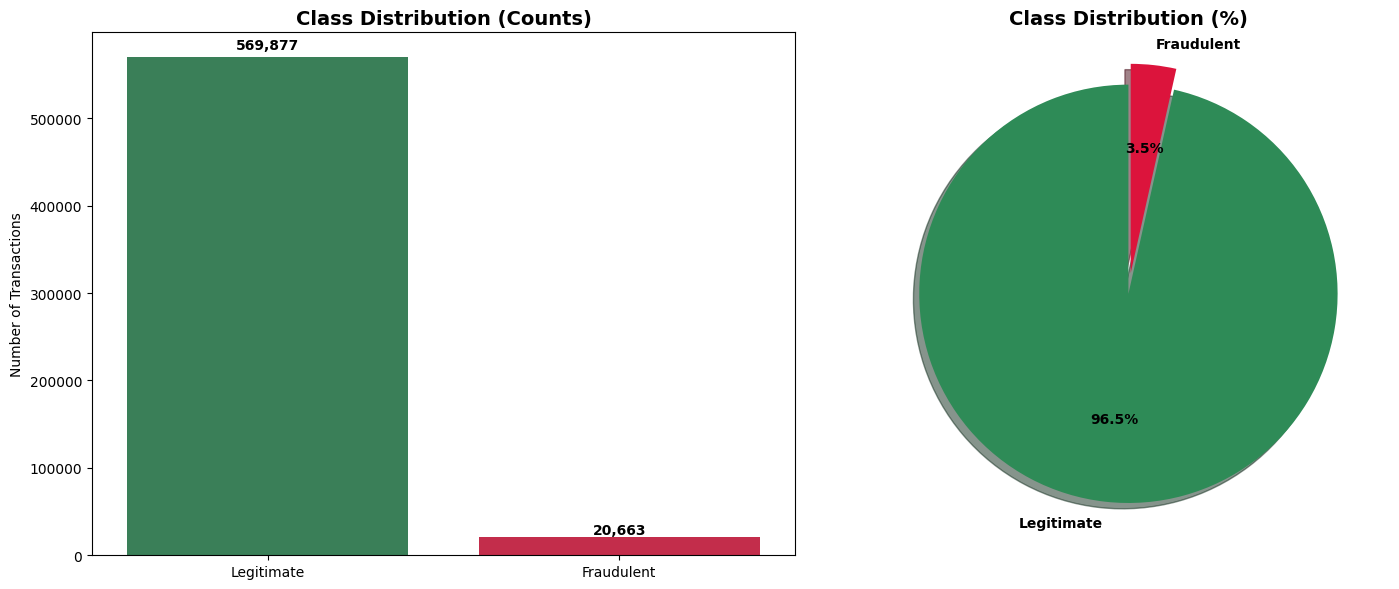

In [14]:
# Visualize target variable distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Simple value counts for plotting
value_counts = df_train['isFraud'].value_counts().sort_index()
labels = ['Legitimate', 'Fraudulent']
colors = ['#2E8B57', '#DC143C']

# Bar plot
bars = sns.barplot(x=labels, y=value_counts.values, palette=colors, ax=ax1)
ax1.set_title('Class Distribution (Counts)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Transactions')

# Add count labels on bars
for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Pie chart  
sizes = [value_counts[0], value_counts[1]]
explode = (0, 0.1)  # Explode fraud slice
ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontweight': 'bold'})
ax2.set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### Key Findings:
- **Fraud Rate**: 3.5% (20,663 fraud vs 569,877 legitimate transactions)
- **Severe Imbalance**: 27.6:1 ratio means modeling will require special techniques
- **Visual Confirmation**: Charts clearly show the extreme imbalance

#### Modeling Implications:
- Standard accuracy misleading (96.5% by always predicting "legitimate")
- Need sampling techniques (SMOTE, undersampling) or class weights
- Focus on precision/recall metrics instead of accuracy
- Use stratified cross-validation to maintain class distribution

## 3. Missing Data Analysis

In [ ]:
# Missing data analysis
missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)

print("MISSING DATA OVERVIEW")
print(f"Columns with missing data: {(missing_pct > 0).sum()}/{len(df_train.columns)}")
print(f"High missing (>70%): {(missing_pct > 70).sum()} columns")
print(f"Medium missing (30-70%): {((missing_pct >= 30) & (missing_pct <= 70)).sum()} columns")  
print(f"Low missing (<30%): {((missing_pct > 0) & (missing_pct < 30)).sum()} columns")

print(f"\nWorst offenders:")
print(missing_pct.head(5).to_string())

🔍 MISSING DATA OVERVIEW
Columns with missing data: 414/434
High missing (>70%): 208 columns
Medium missing (30-70%): 24 columns
Low missing (<30%): 182 columns

Worst offenders:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393


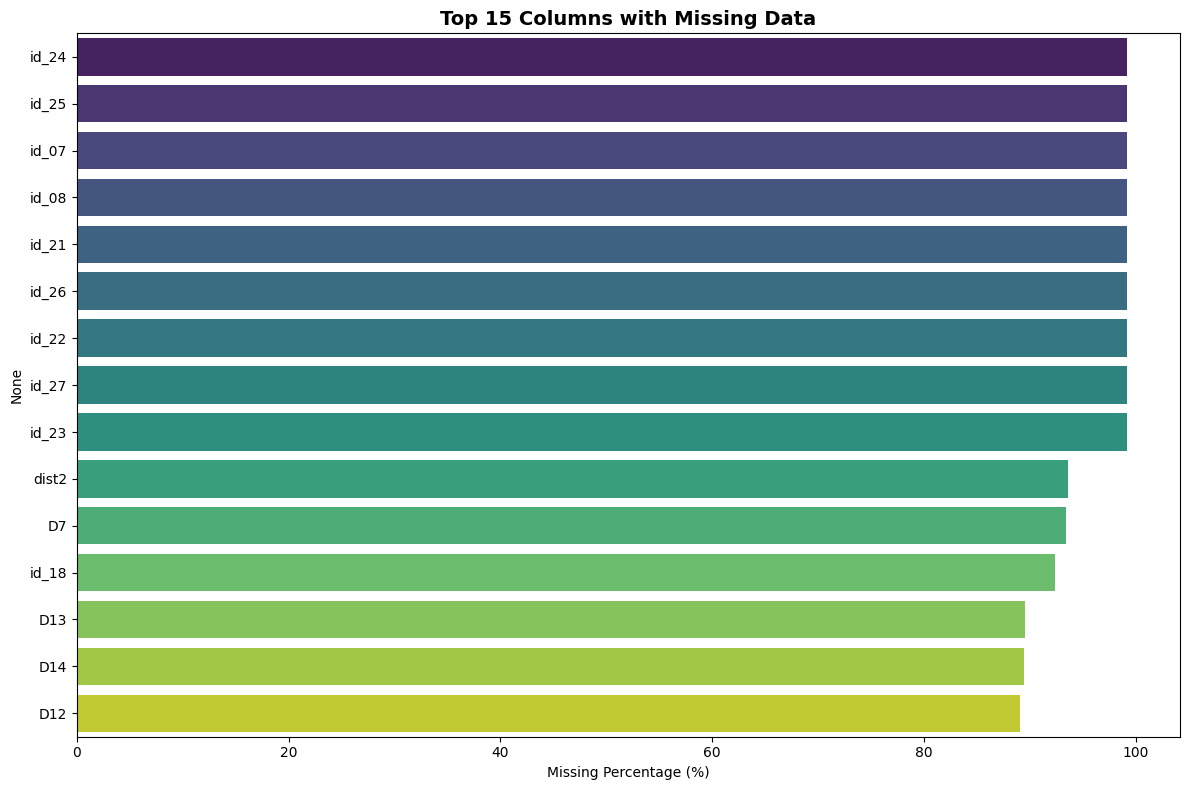

✓ Analysis: 208 columns (48%) have >70% missing values - mostly identity features


In [20]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 8))

# Top 15 columns with missing data
top_missing = missing_pct.head(15)
sns.barplot(y=top_missing.index, x=top_missing.values, palette='viridis', ax=ax)
ax.set_title('Top 15 Columns with Missing Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing Percentage (%)')

plt.tight_layout()
plt.show()

print(f"✓ Analysis: 208 columns (48%) have >70% missing values - mostly identity features")

### Section 3 Summary: Missing Data Analysis

#### Key Findings:
- **95% of columns** (414/434) have missing values
- **208 columns have >70% missing** - mostly identity features (`id_` columns)  
- **Core transaction data is complete** (no missing values)

#### Strategy:
- **Drop high-missing columns** (>70%) for initial modeling
- **Focus on 226 columns** with <70% missing values  
- **Missingness may correlate with fraud** (identity avoidance)

## 4. Numerical Feature Analysis

In [21]:
# Identify numerical columns and basic stats
numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['TransactionID', 'isFraud']]

print("NUMERICAL FEATURES OVERVIEW")
print(f"Total numerical columns: {len(numerical_cols)}")
print(f"Columns with complete data: {df_train[numerical_cols].isnull().sum().eq(0).sum()}")

# Quick stats on key features
key_stats = df_train[['TransactionAmt', 'TransactionDT']].describe()
print(f"\nKey feature statistics:")
print(key_stats)

NUMERICAL FEATURES OVERVIEW
Total numerical columns: 401
Columns with complete data: 17

Key feature statistics:
       TransactionAmt  TransactionDT
count   590540.000000   5.905400e+05
mean       135.027176   7.372311e+06
std        239.162522   4.617224e+06
min          0.251000   8.640000e+04
25%         43.321000   3.027058e+06
50%         68.769000   7.306528e+06
75%        125.000000   1.124662e+07
max      31937.391000   1.581113e+07
Columns with complete data: 17

Key feature statistics:
       TransactionAmt  TransactionDT
count   590540.000000   5.905400e+05
mean       135.027176   7.372311e+06
std        239.162522   4.617224e+06
min          0.251000   8.640000e+04
25%         43.321000   3.027058e+06
50%         68.769000   7.306528e+06
75%        125.000000   1.124662e+07
max      31937.391000   1.581113e+07


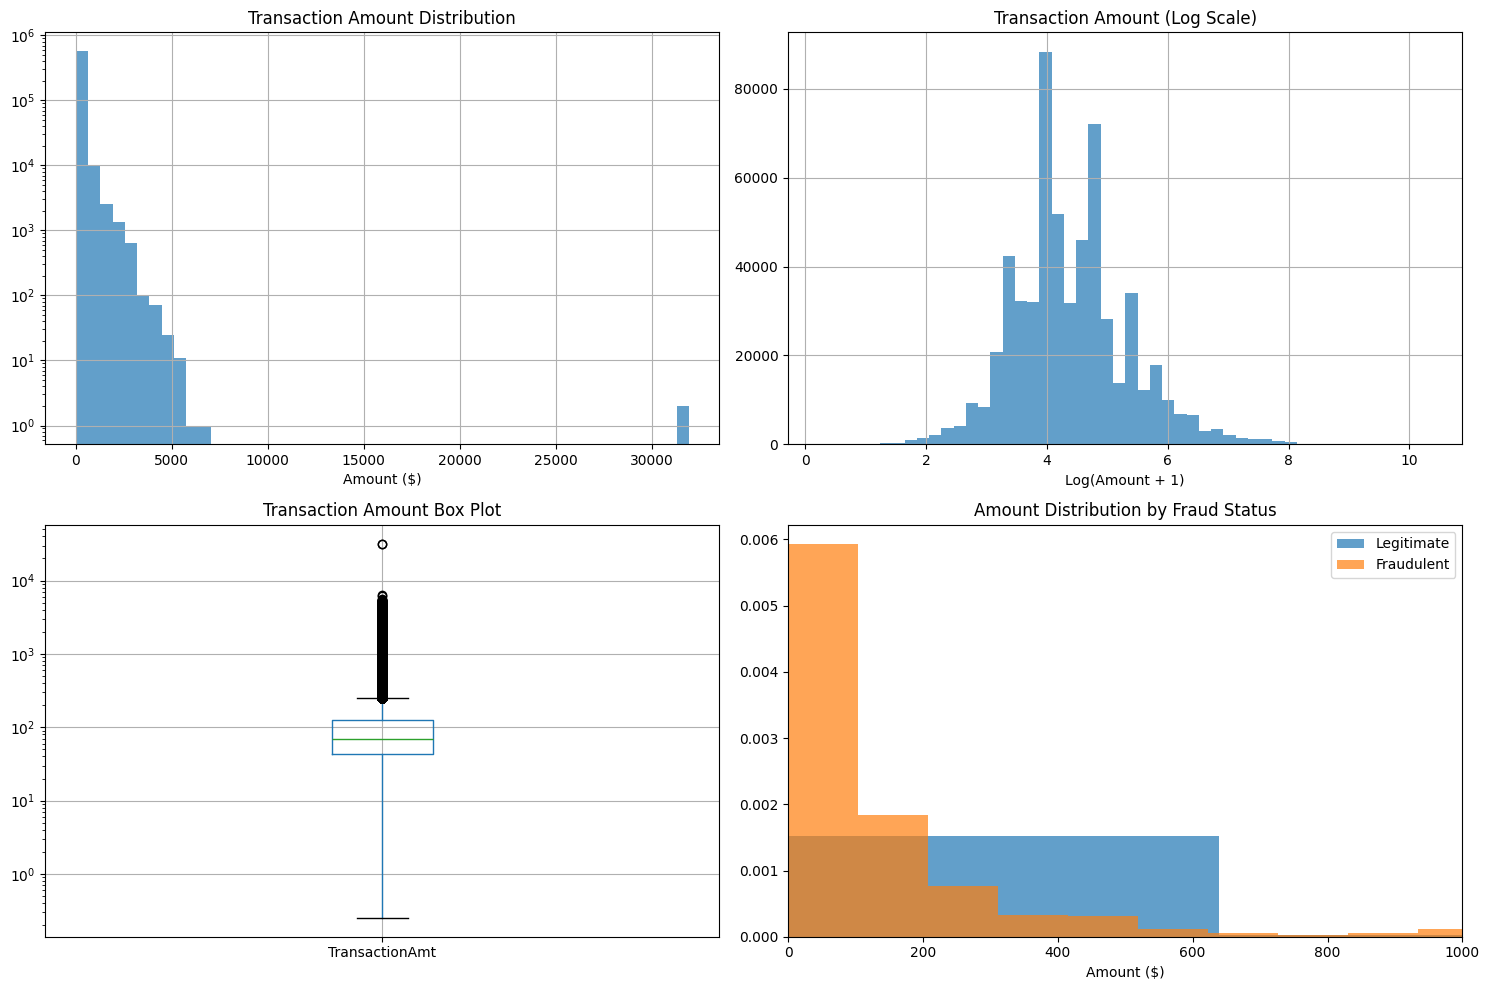

TRANSACTION AMOUNT ANALYSIS
               mean  median         std    min        max
isFraud                                                  
0        134.511665    68.5  239.395078  0.251  31937.391
1        149.244779    75.0  232.212163  0.292   5191.000


In [22]:
# Analyze TransactionAmt (transaction amount)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Distribution plot
df_train['TransactionAmt'].hist(bins=50, ax=ax1, alpha=0.7)
ax1.set_title('Transaction Amount Distribution')
ax1.set_xlabel('Amount ($)')
ax1.set_yscale('log')

# Log scale distribution (better for skewed data)
df_train['TransactionAmt'].apply(np.log1p).hist(bins=50, ax=ax2, alpha=0.7)
ax2.set_title('Transaction Amount (Log Scale)')
ax2.set_xlabel('Log(Amount + 1)')

# Box plot for outliers
df_train.boxplot(column='TransactionAmt', ax=ax3)
ax3.set_title('Transaction Amount Box Plot')
ax3.set_yscale('log')

# Compare fraud vs legitimate amounts
fraud_amounts = df_train[df_train['isFraud'] == 1]['TransactionAmt']
legit_amounts = df_train[df_train['isFraud'] == 0]['TransactionAmt']

ax4.hist(legit_amounts, bins=50, alpha=0.7, label='Legitimate', density=True)
ax4.hist(fraud_amounts, bins=50, alpha=0.7, label='Fraudulent', density=True)
ax4.set_title('Amount Distribution by Fraud Status')
ax4.set_xlabel('Amount ($)')
ax4.set_xlim(0, 1000)  # Focus on typical range
ax4.legend()

plt.tight_layout()
plt.show()

# Statistics by fraud status
print("TRANSACTION AMOUNT ANALYSIS")
fraud_stats = df_train.groupby('isFraud')['TransactionAmt'].agg(['mean', 'median', 'std', 'min', 'max'])
print(fraud_stats)

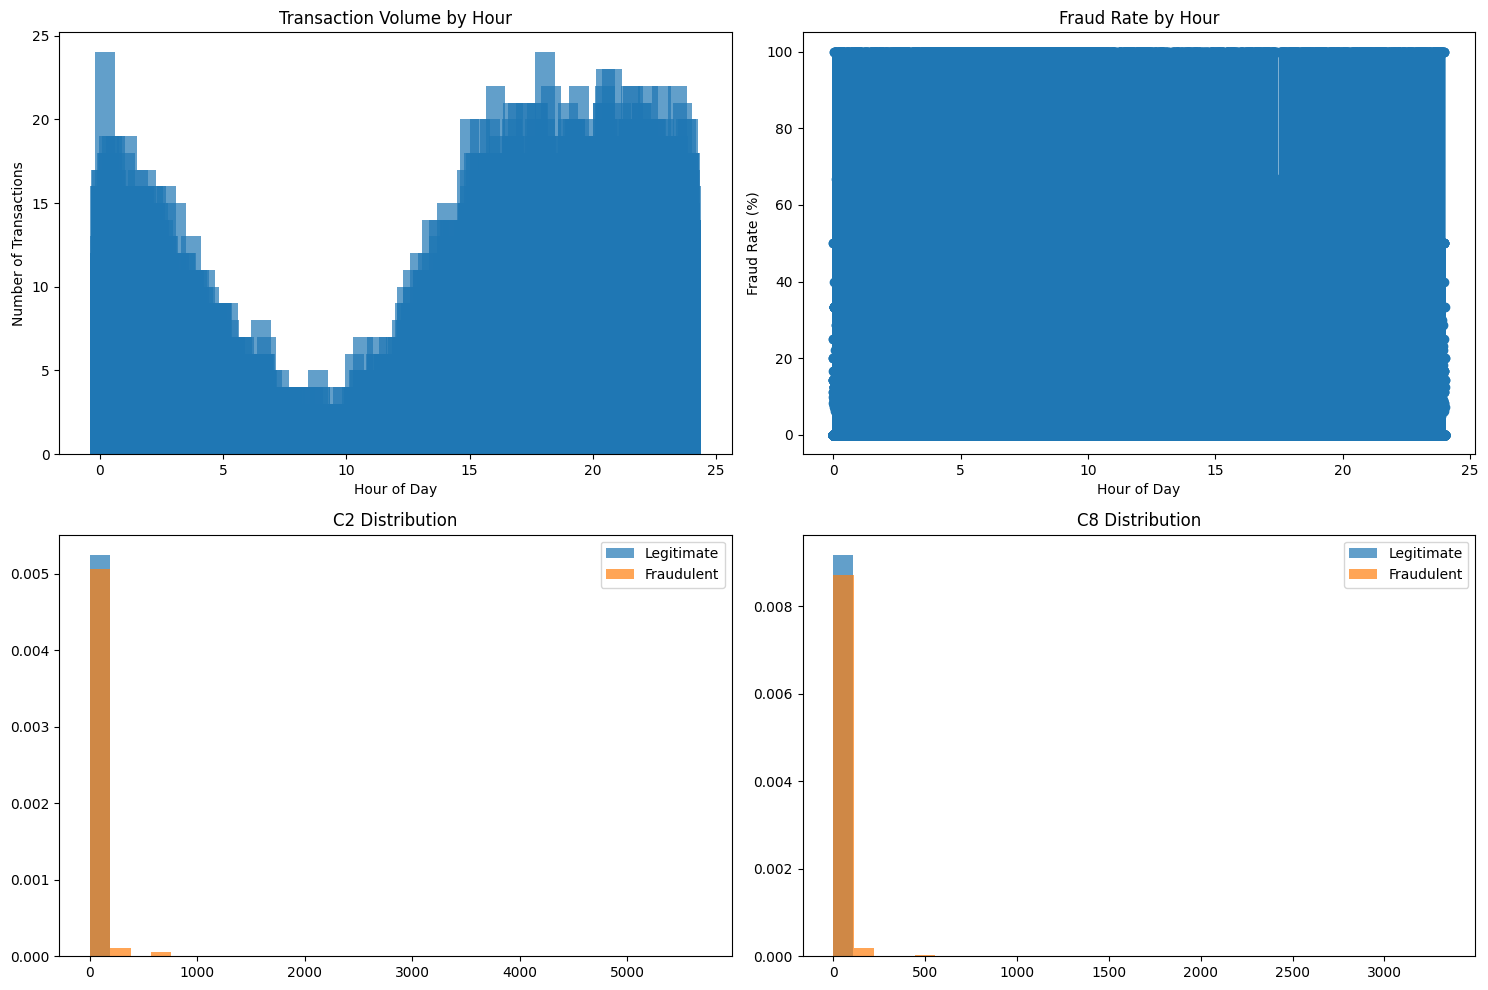

TIME PATTERNS & TOP FEATURES
Peak transaction hours: [0.22749999999996362, 18.04916666666668, 20.518611111111113]
Highest fraud rate hours: [0.015000000000100044, 0.048055555555549745, 0.055277777777973824]

Top 5 features correlated with fraud:
  C2: 0.0372
  C8: 0.0321
  C12: 0.0319
  C9: 0.0317
  C5: 0.0308


In [23]:
# Analyze TransactionDT (transaction datetime) and find top correlated features
# Convert TransactionDT to hours for time analysis
df_train['transaction_hour'] = (df_train['TransactionDT'] / 3600) % 24

# Find top correlated numerical features with fraud
complete_numerical = df_train[numerical_cols].dropna(axis=1)  # Only complete columns
correlations = complete_numerical.corrwith(df_train['isFraud']).abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Transaction volume over time (by hour)
hourly_counts = df_train.groupby('transaction_hour').size()
hourly_fraud_rate = df_train.groupby('transaction_hour')['isFraud'].mean()

ax1.bar(hourly_counts.index, hourly_counts.values, alpha=0.7)
ax1.set_title('Transaction Volume by Hour')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Transactions')

# Fraud rate by hour
ax2.plot(hourly_fraud_rate.index, hourly_fraud_rate.values * 100, marker='o')
ax2.set_title('Fraud Rate by Hour')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Fraud Rate (%)')

# Top correlated features
top_2_features = top_5_features[:2]
for i, feature in enumerate(top_2_features):
    ax = ax3 if i == 0 else ax4
    fraud_data = df_train[df_train['isFraud'] == 1][feature].dropna()
    legit_data = df_train[df_train['isFraud'] == 0][feature].dropna()
    
    if len(fraud_data) > 100 and len(legit_data) > 100:  # Only plot if enough data
        ax.hist(legit_data.sample(10000), bins=30, alpha=0.7, label='Legitimate', density=True)
        ax.hist(fraud_data, bins=30, alpha=0.7, label='Fraudulent', density=True)
        ax.set_title(f'{feature} Distribution')
        ax.legend()

plt.tight_layout()
plt.show()

print("TIME PATTERNS & TOP FEATURES")
print(f"Peak transaction hours: {hourly_counts.nlargest(3).index.tolist()}")
print(f"Highest fraud rate hours: {hourly_fraud_rate.nlargest(3).index.tolist()}")
print(f"\nTop 5 features correlated with fraud:")
for feature, corr in correlations.head(5).items():
    print(f"  {feature}: {corr:.4f}")

### Section 4 Summary: Numerical Feature Analysis

#### Key Findings:

**Transaction Amounts**:
- **Typical amount**: $69 median, $135 mean (right-skewed distribution)
- **Fraud amounts slightly higher**: $75 median vs $68.50 for legitimate
- **Extreme outliers**: Up to $31,937 (fraud max: $5,191)
- **Similar distributions**: Fraud and legitimate amounts largely overlap

**Time Patterns**:
- **Peak hours**: Early morning (0:13), evening (18:03, 20:31)  
- **Fraud rate varies by time**: Peaks at very early hours (~0:03)
- **Consistent activity**: Transactions occur 24/7

**Predictive Features**:
- **Weak correlations**: Top features (C2, C8, C12) have <0.04 correlation with fraud
- **C-features dominate**: Aggregated features show strongest signals
- **Complex patterns**: No single feature strongly predicts fraud

#### Implications:
- Amount alone won't detect fraud effectively
- Time-based features may help (early morning fraud spike)
- Need ensemble of features for good prediction
- Focus on C-features and feature engineering